In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from qiskit.circuit.library import PermutationGate
from qiskit.circuit.library import QFTGate
from math import pi
import numpy as np
import random
import galois

In [2]:
def m_a_perm(a, mod, n):
    where_do_i_go = []
    for i in range(mod):
        where_do_i_go.append((i * a) % mod)
    for i in range(mod, n):
        where_do_i_go.append(i)
    return where_do_i_go

In [3]:
m_a_perm(4, 10, 15)

[0, 4, 8, 2, 6, 0, 4, 8, 2, 6, 10, 11, 12, 13, 14]

In [4]:
def function_circuit(num_q_inp, num_q_out, inp_list, out_list):
    qc = QuantumCircuit(num_q_inp + num_q_out)

    def flip_bitmask(mask):
        for i in range(num_q_inp):
            if (mask & (2 ** i)) == 0:
                qc.x(i)

    def turn_bit_on(key, turn):
        flip_bitmask(key)
        qc.mcx(list(range(num_q_inp)), turn)
        flip_bitmask(key)

    for (inp, out) in zip(inp_list, out_list):
        #qc.barrier()
        for i in range(2 ** num_q_out):
            if (out & (2 ** i)) != 0:
                turn_bit_on(inp, i + num_q_inp)

    return qc

In [5]:
def ma_circuit(a, mod, num_b, inp_list, out_list):
    perm = m_a_perm(a, mod, 1 << num_b)
    #print(perm)
    fun_circ = function_circuit(num_b, num_b, range(0,1<<num_b), perm)
    return fun_circ

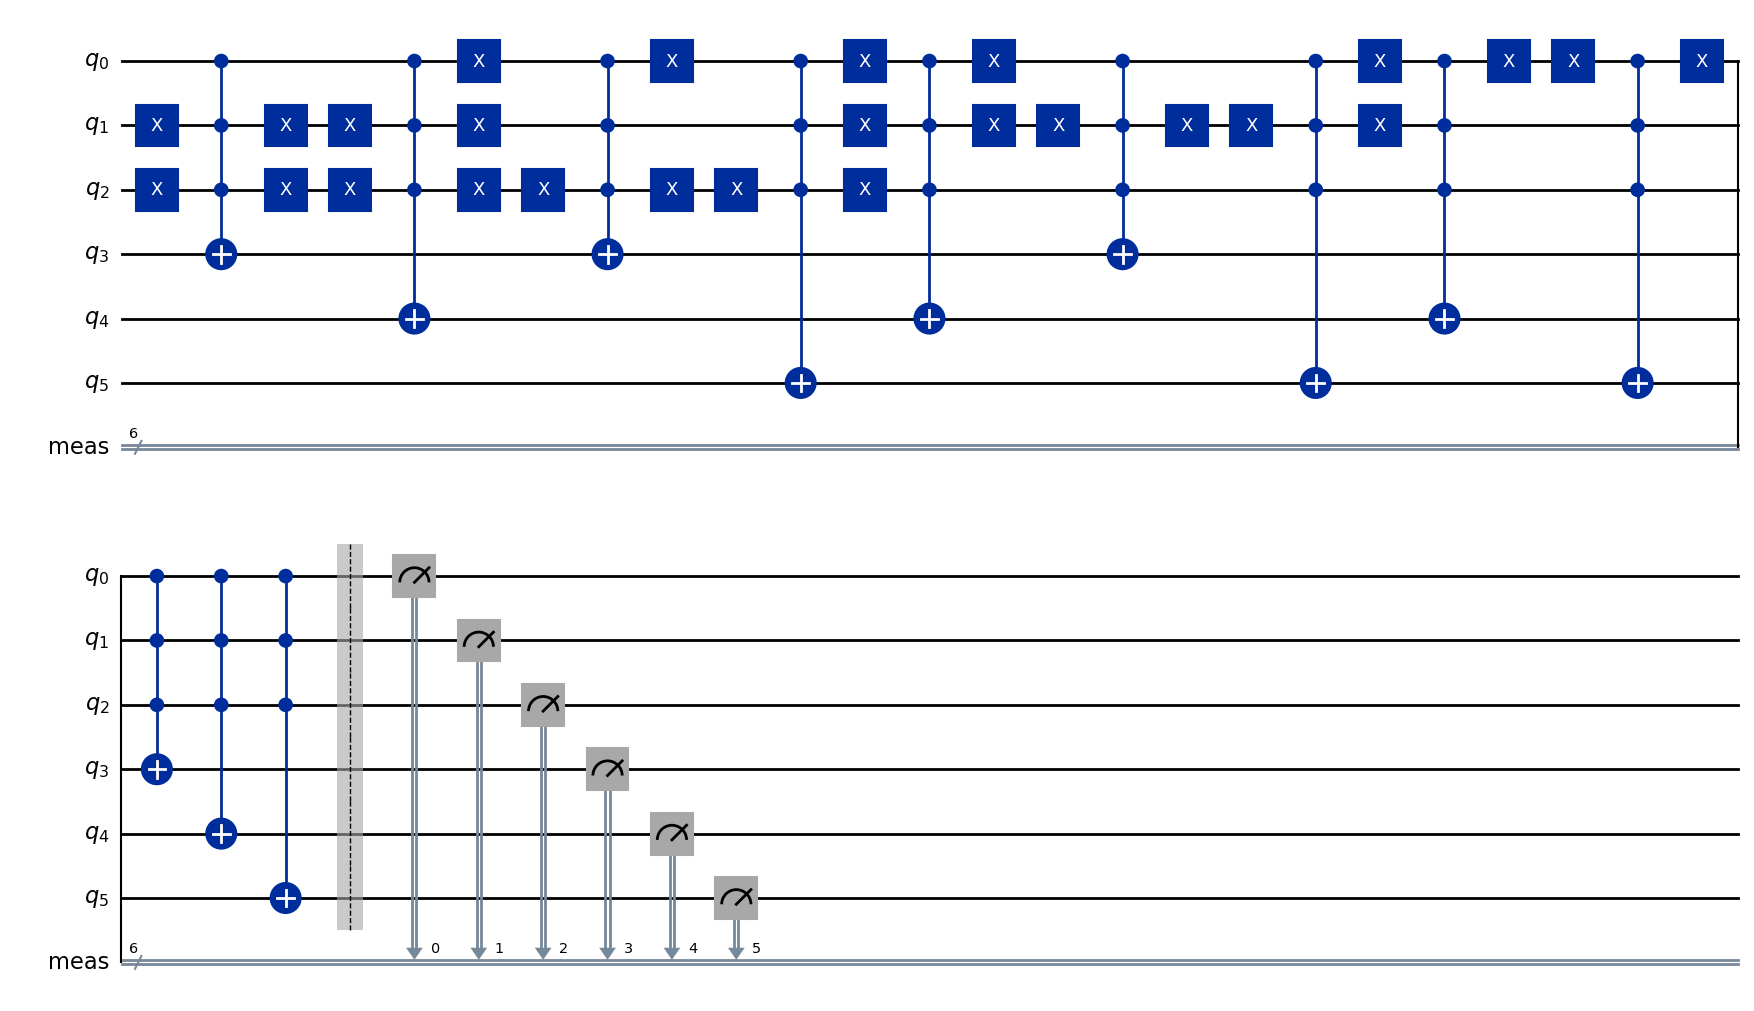

In [6]:
qc = QuantumCircuit(6)
ma_circ = ma_circuit(3, 5, 3, range(3), range(3, 6))
qc = qc.compose(ma_circ)
qc.measure_all()
display(qc.draw("mpl"))

In [7]:
def in_place_ma(a, mod, num_b):
    qc = ma_circuit(a, mod, num_b, 
                        range(1 << num_b), 
                        range(1 << num_b, 2 << num_b))
    # swap top and bottom
    for i in range(num_b):
        qc.swap(i, i + num_b)

    # now state is |f(x)>|x>
    # apply  f^-1 with f(x) as control
    # goes to |f(x)>|x XOR f^-1(f(x))> = |f(x)>|0>

    inverse = ma_circuit(a, mod, num_b, 
                        range(1 << num_b), 
                        range(1 << num_b, 2 << num_b)).inverse()
    qc = qc.compose(inverse)
    
    return qc

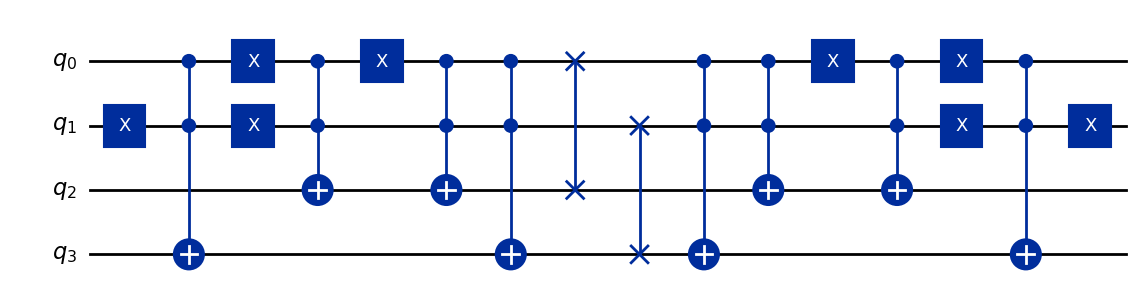

In [8]:
display(in_place_ma(2, 3, 2).draw("mpl"))

In [9]:
qc = QuantumCircuit(4)
#qc.x(1)
qc.x(1)
qc.barrier()
qc = qc.compose(in_place_ma(2, 3, 2))
qc.measure_all()

result = AerSimulator().run(qc, shots=1).result()
statistics = result.get_counts()
print(statistics)

{'0001': 1}


In [10]:
def ma_gate(a, mod, num_b):
    gate = in_place_ma(a, mod, num_b).to_gate()
    gate.name = ("m_" + str(a) + " mod " + str(mod))
    return gate

def c_ma_gate(a, mod, num_b):
    return ma_gate(a, mod, num_b).control(1)

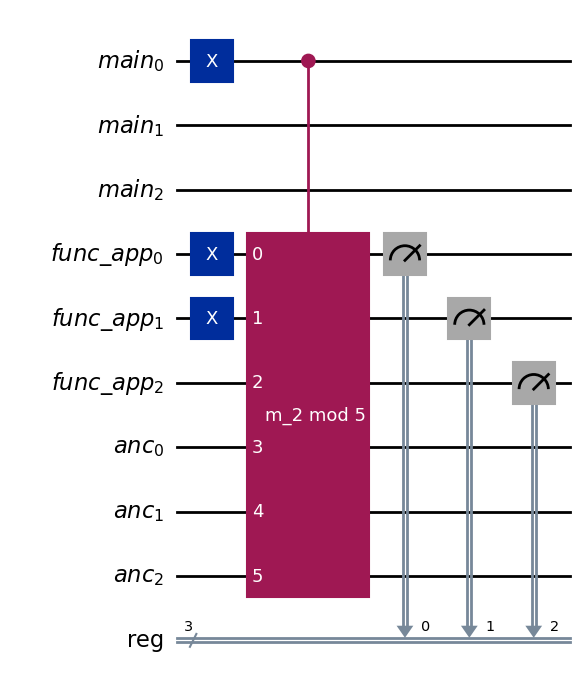

2 5 1
001


In [11]:
m=3
ancilla = QuantumRegister(m, "anc")
func_app = QuantumRegister(m, "func_app")
main = QuantumRegister(m, "main")
reg = ClassicalRegister(m, "reg")
qc = QuantumCircuit(main, func_app, ancilla, reg)

qc.x(main[0])
qc.x(func_app[0])
qc.x(func_app[1])
#qc.x(func_app[2])
mod = 5
a = 2

qc.append(c_ma_gate(a, mod, m), [main[0], *func_app, *ancilla])

qc.measure(func_app, reg)

display(qc.draw("mpl"))

sim = AerSimulator()
qc_t = transpile(qc, sim)
result = sim.run(qc_t, shots=1).result()
statistics = result.get_counts()
bitstring = list(statistics.keys())[0]
number = int(bitstring, 2)
print(a, mod, number)
print(bitstring)

In [12]:
# m is number of precision bits
# n is modulo
# a is thing we want to find order of
def shors_algo(m, n, a):
    ancilla = QuantumRegister(m, "anc")
    func_app = QuantumRegister(m, "func_app")
    main = QuantumRegister(m, "main")
    register = ClassicalRegister(m, "reg")
    qc = QuantumCircuit(main, func_app, ancilla, register)
    # establish superposition
    qc.h(main)

    #get superposition of interesting eigenvectors of m_a mod n
    qc.x(func_app[0])

    # phase kickback
    curr_mul = a
    for i in range(0, m):
        qc.append(c_ma_gate(curr_mul, n, m), [main[i], *func_app, *ancilla])
        curr_mul = (curr_mul * curr_mul) % n

    qc.append(QFTGate(m).inverse(), main)
    qc.measure(main, register)
    
    return qc
# q1 -----U--U--U----
# q2 -----U--U--U-------
# we only want to do this on the 1 compontents
# how to do in place?
# a|0> + b|1> -> a|0> 

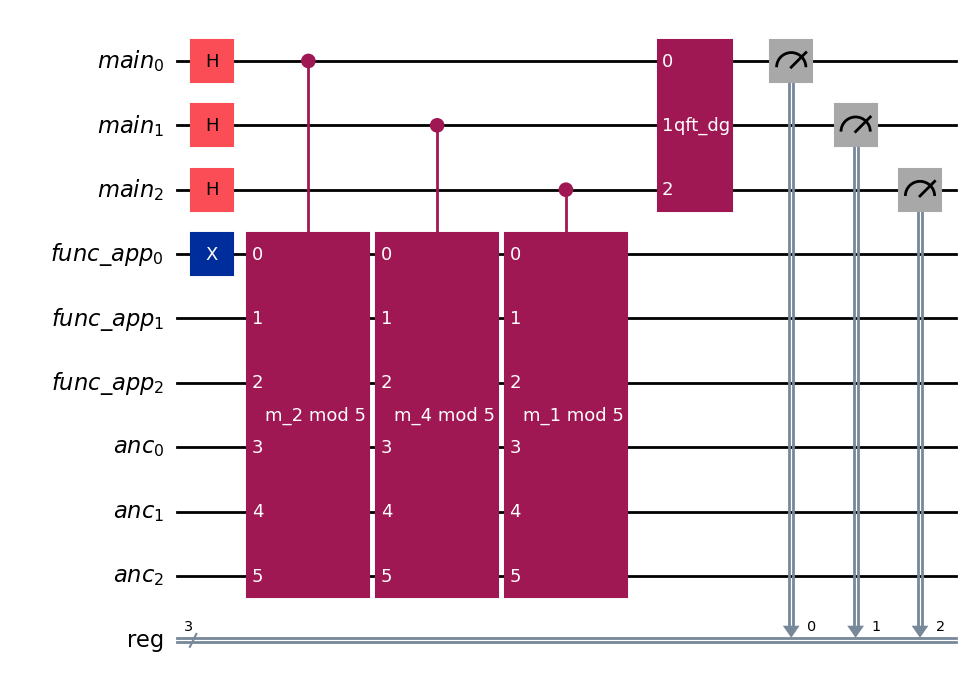

In [13]:
display(shors_algo(3, 5, 2).draw("mpl"))

In [28]:
def counts_bitstring_to_int(counts):
    """
    Convert a Qiskit counts dict with bitstring keys
    to a dict with integer keys.
    
    Example:
    {'101': 3, '011': 1} -> {5: 3, 3: 1}
    """
    return {int(bitstring, 2): shots for bitstring, shots in counts.items()}
m = 6
n = 5
a = 2
qc = shors_algo(m, n, a)

sim = AerSimulator()
qc_t = transpile(qc, sim)
print("DONE TRANSPILING")

DONE TRANSPILING


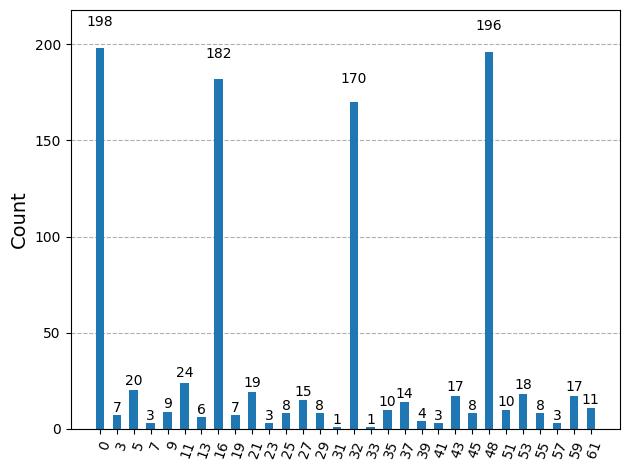

In [29]:
result = sim.run(qc_t, shots=1000).result()
statistics = result.get_counts()
int_map = counts_bitstring_to_int(statistics)
display(plot_histogram(int_map))

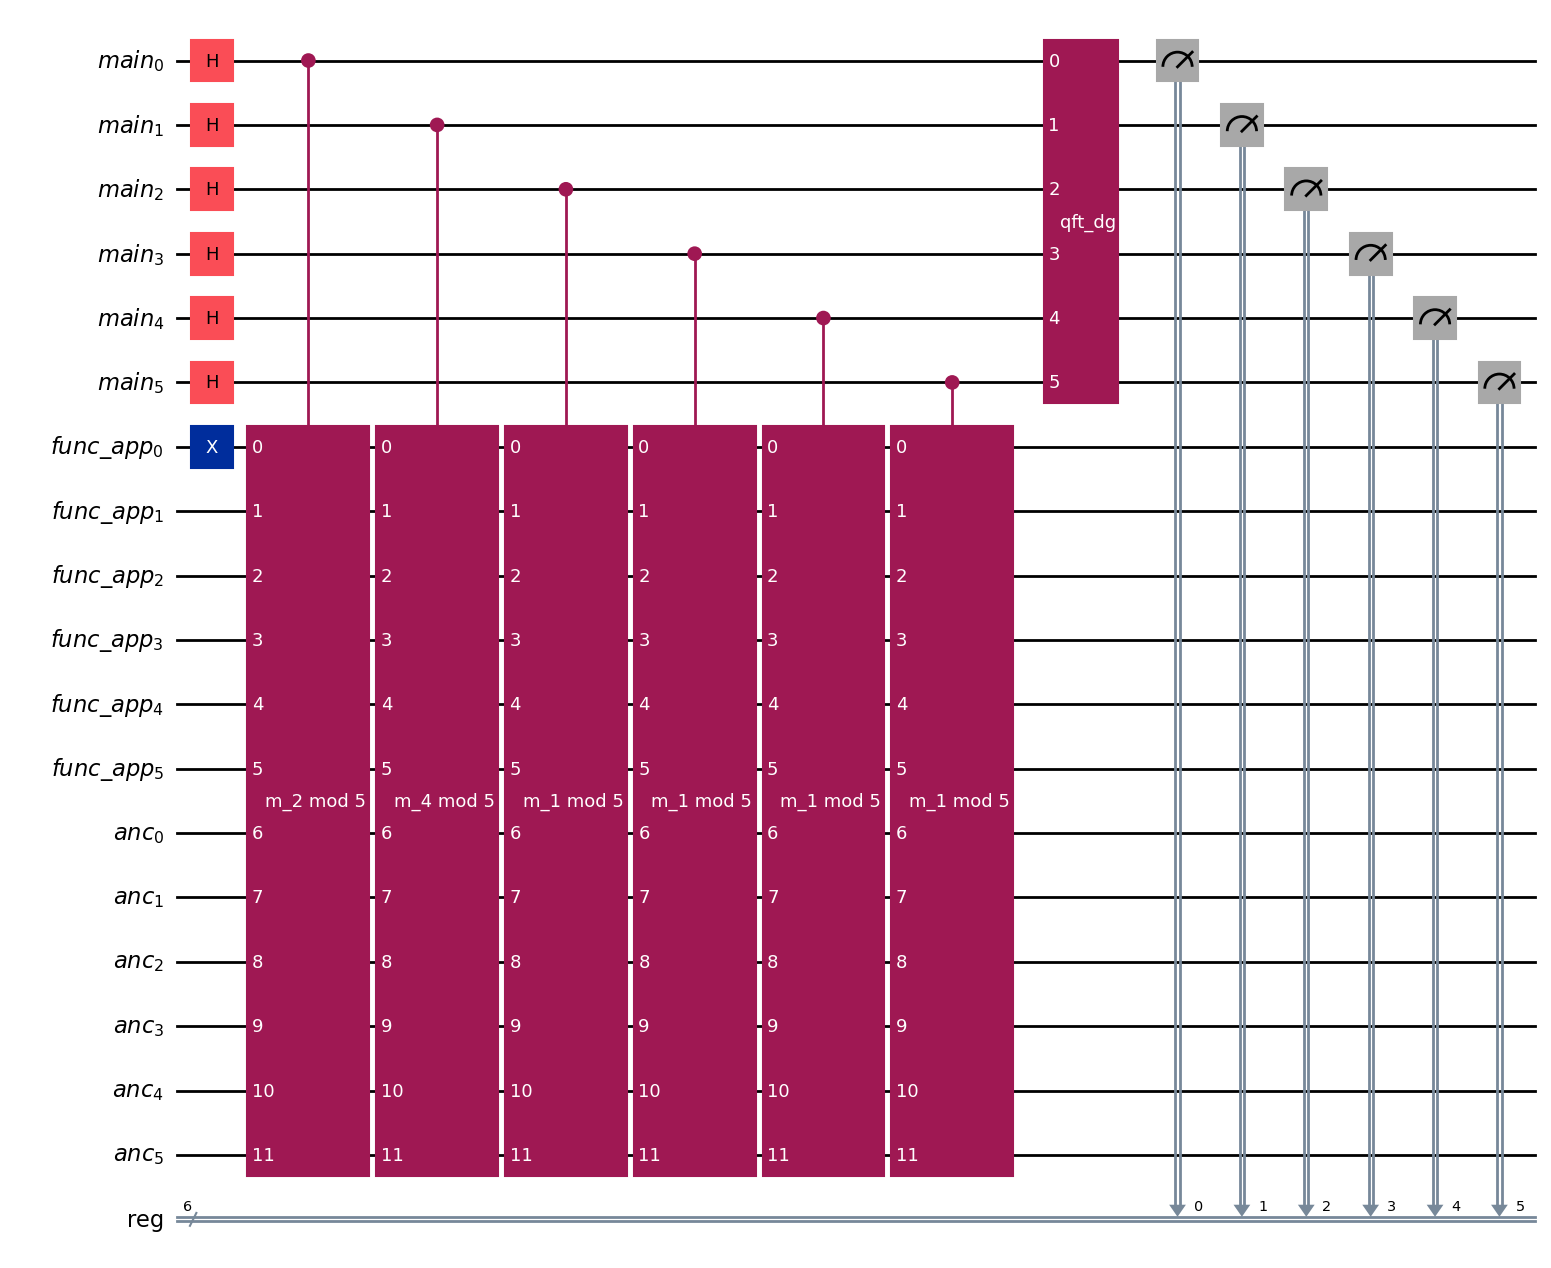

In [30]:
display(qc.draw("mpl"))